# Audit Overfitting Ulang — Universe 40 Coin (replikasi notebook 08)

Notebook 10 menunjukkan rotasi momentum (F2) kehilangan sebagian besar keunggulannya di 40 coin,
sementara **filter tren BTC (F1)** jadi kandidat terkuat. Notebook ini mengaudit **keduanya** dengan
uji yang sama seperti notebook 08, plus uji khusus F1:

| # | Uji | Untuk |
|---|---|---|
| 1 | PBO / CSCV | F2 (144 konfigurasi) & F1 (28 konfigurasi) |
| 2 | Deflated Sharpe Ratio | F2 Konservatif 07 & F1 MA50 |
| 3 | Walk-forward tahunan | F2 & F1 |
| 4 | Uji nol: pilihan coin acak | F2 |
| 5 | Uji nol: timing acak (exposure sama) | F1 |
| 6 | Kestabilan parameter (plateau MA) | F1 |
| 7 | **Data segar 2018–2020** (belum pernah dipakai riset mana pun) | F1 |
| 8 | Bootstrap Sharpe | F1, F2, BTC |

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")

import itertools
from math import comb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from data_source.loader import load_symbol, discover_symbols
from src.databases import get_connection
from src.services.recommendation.service import MIN_VOLATILITY
from research.single_position import Panel, run, metrics, pretty, f2_target, f1_target, ranked_target, BTC

pd.set_option("display.width", 180); pd.set_option("display.max_columns", 30)
TRAIN, TEST, FULL = ("2021-01-01", "2023-12-31"), ("2024-01-01", "2026-06-30"), ("2021-01-01", "2026-06-30")

with get_connection() as conn:
    lm = [r[0] for r in conn.execute(
        "SELECT value_param FROM flex_params WHERE type_param='SIMBOL_CRYPTO' AND deleted_at IS NULL "
        "AND description IN ('Large','Mid')").fetchall()]
raw = {s: load_symbol(s, "1d", "full") for s in lm if s in set(discover_symbols("1d", "full"))}
P_all = Panel(raw, "2018-01-01", "2026-06-30")
UNIV = sorted(s for s in raw if P_all.atr_pct[s].median() >= MIN_VOLATILITY and s not in ("PAXGUSDT", "XAUTUSDT", "WBETHUSDT"))
P = Panel({s: raw[s] for s in UNIV}, "2018-01-01", "2026-06-30")
print(f"Universe: {len(UNIV)} coin (sama dengan notebook 10)")

KONS07 = dict(ma_n=50, L=14, R=1, tv=0.02, cdd=0.15)
GRID = list(itertools.product((50, 100), (14, 30), (1, 3, 7), (0.0, 0.02, 0.03), (0.0, 0.15, 0.20, 0.25)))
KEYS = ["ma_n", "L", "R", "tv", "cdd"]
F1_GRID = [(n, kind, trail) for n in (20, 30, 50, 75, 100, 150, 200) for kind in ("sma", "ema") for trail in (None, 3.0)]


def sim(Pn, c, start, end, **kw):
    tgt = f2_target(Pn, c["ma_n"], c["L"], c["R"])
    size = (c["tv"] / Pn.vol(20)).clip(upper=1) if c["tv"] else None
    return run(Pn, tgt, start, end, size=size, circuit_dd=c["cdd"] or None, **kw)


def daily_sharpe(r):
    r = np.asarray(r)
    return r.mean() / r.std() if r.std() > 0 else 0.0


hold = pd.Series(BTC, index=P.dates)
btc_test = metrics(*run(P, hold, *TEST))

Universe: 40 coin (sama dengan notebook 10)


## 1. PBO (CSCV) — F2 dan F1

Sama seperti notebook 08: return harian semua konfigurasi 2021-01 → 2026-06 dipotong 16 blok,
12.870 cara membagi in-sample/out-of-sample. PBO < 20% bagus, ≈ 50% overfit total.

In [2]:
def cscv(R_mat, S=16):
    X = R_mat.to_numpy(); T, K = X.shape
    blocks = np.array_split(np.arange(T), S)
    bsum = np.array([X[b].sum(0) for b in blocks]); bsq = np.array([(X[b] ** 2).sum(0) for b in blocks])
    bn = np.array([len(b) for b in blocks])
    def sharpe(idx):
        n = bn[idx].sum(); m = bsum[idx].sum(0) / n
        return m / np.sqrt(np.maximum(bsq[idx].sum(0) / n - m ** 2, 1e-18))
    logits, oos_best, oos_med = [], [], []
    for is_idx in itertools.combinations(range(S), S // 2):
        is_idx = list(is_idx); oos_idx = [b for b in range(S) if b not in is_idx]
        sr_is, sr_oos = sharpe(is_idx), sharpe(oos_idx)
        best = int(np.argmax(sr_is))
        w = stats.rankdata(sr_oos)[best] / (K + 1)
        logits.append(np.log(w / (1 - w))); oos_best.append(sr_oos[best]); oos_med.append(np.median(sr_oos))
    logits = np.array(logits)
    return dict(PBO=(logits <= 0).mean(), sharpe_oos_juara=np.median(oos_best) * np.sqrt(365),
                sharpe_oos_median_semua=np.median(oos_med) * np.sqrt(365),
                peluang_juara_rugi_oos=(np.array(oos_best) < 0).mean())

R_f2 = pd.DataFrame({combo: sim(P, dict(zip(KEYS, combo)), *FULL)[1].pct_change().fillna(0) for combo in GRID})
R_f1 = pd.DataFrame({cfg: run(P, f1_target(P, cfg[0], cfg[1]), *FULL, trail_atr=cfg[2])[1].pct_change().fillna(0)
                     for cfg in F1_GRID})
pbo = pd.DataFrame({"F2 rotasi momentum (144)": cscv(R_f2), "F1 tren BTC (28)": cscv(R_f1)}).T
pretty(pbo, pct=["PBO", "peluang_juara_rugi_oos"], dec=["sharpe_oos_juara", "sharpe_oos_median_semua"])

,PBO,sharpe_oos_juara,sharpe_oos_median_semua,peluang_juara_rugi_oos
F2 rotasi momentum (144),+61.4%,0.55,0.72,+14.6%
F1 tren BTC (28),+71.9%,0.42,0.61,+18.2%


## 2. Deflated Sharpe Ratio

Jumlah percobaan jujur sejak notebook 07: 07+08 (~338) + notebook 10 (54 screening + 144 grid) ≈ **536**.

In [3]:
def expected_max_sharpe(n, var_sr):
    g = 0.5772156649
    return np.sqrt(var_sr) * ((1 - g) * stats.norm.ppf(1 - 1 / n) + g * stats.norm.ppf(1 - 1 / (n * np.e)))

def dsr(r, sr0):
    r = np.asarray(r); sr = daily_sharpe(r)
    sk, ku = stats.skew(r), stats.kurtosis(r, fisher=False)
    return stats.norm.cdf((sr - sr0) * np.sqrt(len(r) - 1) / np.sqrt(1 - sk * sr + (ku - 1) / 4 * sr ** 2)), sr

mask = (R_f2.index >= TEST[0]) & (R_f2.index <= TEST[1])
var_sr = np.var([daily_sharpe(R_f2.loc[mask, k]) for k in R_f2.columns] + [daily_sharpe(R_f1.loc[mask, k]) for k in R_f1.columns])
cands = {"F2 Konservatif 07 (40 coin)": sim(P, KONS07, *TEST)[1], "F1 tren BTC SMA50": run(P, f1_target(P, 50), *TEST)[1]}
rows = []
for name, eq in cands.items():
    r = eq.pct_change().dropna()
    for n in (1, 28, 536):
        sr0 = expected_max_sharpe(n, var_sr) if n > 1 else 0.0
        p, sr = dsr(r, sr0)
        rows.append(dict(strategi=name, n_percobaan=n, sharpe=sr * np.sqrt(365), batas_kebetulan=sr0 * np.sqrt(365), DSR=p))
pretty(pd.DataFrame(rows).set_index(["strategi", "n_percobaan"]), pct=["DSR"], dec=["sharpe", "batas_kebetulan"])

sharpe batas_kebetulan     DSR
strategi                    n_percobaan                               
F2 Konservatif 07 (40 coin) 1             0.47            0.00  +77.4%
                            28            0.47            0.74  +32.8%
                            536           0.47            1.11  +14.7%
F1 tren BTC SMA50           1             0.77            0.00  +89.2%
                            28            0.77            0.74  +52.0%
                            536           0.77            1.11  +29.2%

## 3. Walk-forward tahunan (pilih ulang parameter tiap tahun dari data lalu saja)

- F2: pilih dari 144 grid (Calmar tertinggi 2021 → akhir tahun sebelumnya).
- F1: pilih panjang SMA dari {20, 30, 50, 75, 100, 150, 200} dengan cara yang sama.

In [4]:
rows, chains = [], {"F2 walk-forward": [], "F1 walk-forward": []}
for Y in range(2022, 2027):
    te = (f"{Y}-01-01", f"{Y}-12-31" if Y < 2026 else TEST[1])
    tr_end = f"{Y - 1}-12-31"
    c2 = max((dict(zip(KEYS, combo)) for combo in GRID),
             key=lambda c: np.nan_to_num(metrics(*sim(P, c, "2021-01-01", tr_end))["calmar"], nan=-9))
    n1 = max((20, 30, 50, 75, 100, 150, 200),
             key=lambda n: np.nan_to_num(metrics(*run(P, f1_target(P, n), "2021-01-01", tr_end))["calmar"], nan=-9))
    _, e2 = sim(P, c2, *te); _, e1 = run(P, f1_target(P, n1), *te)
    chains["F2 walk-forward"].append(e2 / e2.iloc[0]); chains["F1 walk-forward"].append(e1 / e1.iloc[0])
    b = P.close[BTC][te[0]:te[1]]
    rows.append(dict(tahun=Y, F2_param=str(tuple(c2.values())), F2=e2.iloc[-1] / e2.iloc[0] - 1,
                     F1_SMA=n1, F1=e1.iloc[-1] / e1.iloc[0] - 1, BTC=b.iloc[-1] / b.iloc[0] - 1))
wf = pd.DataFrame(rows).set_index("tahun")
for name, parts in chains.items():
    r = pd.concat([p.pct_change().fillna(0) for p in parts]); eq = (1 + r).cumprod()
    print(f"{name}: total {eq.iloc[-1] - 1:+.1%}, max DD {(eq / eq.cummax() - 1).min():+.1%}, Sharpe {daily_sharpe(r) * np.sqrt(365):.2f}")
bb = P.close[BTC]["2022-01-01":TEST[1]]
print(f"BTC hold      : total {bb.iloc[-1] / bb.iloc[0] - 1:+.1%}, max DD {(bb / bb.cummax() - 1).min():+.1%}")
pretty(wf, pct=["F2", "F1", "BTC"])

F2 walk-forward: total +12.8%, max DD -68.4%, Sharpe 0.39
F1 walk-forward: total +31.9%, max DD -51.0%, Sharpe 0.35
BTC hold      : total +22.8%, max DD -66.9%


,F2_param,F2,F1_SMA,F1,BTC
tahun,,,,,
2022,"(50, 14, 1, 0.03, 0.0)",-28.9%,50,-50.5%,-65.3%
2023,"(50, 14, 1, 0.03, 0.25)",+25.1%,100,+81.2%,+154.5%
2024,"(50, 30, 1, 0.0, 0.0)",+122.1%,100,+56.0%,+111.8%
2025,"(50, 30, 3, 0.0, 0.0)",-39.4%,100,+2.6%,-7.3%
2026,"(100, 30, 3, 0.0, 0.0)",-5.8%,100,-8.1%,-34.0%


## 4. Uji nol F2 — ranking momentum vs pilihan coin acak (200×)

In [5]:
size2 = (0.02 / P.vol(20)).clip(upper=1)
rows = []
for R in (7, 3):
    m_mom = metrics(*run(P, ranked_target(P, 50, 14, R, P.ret(14) / P.vol(14)), *TEST, size=size2, circuit_dd=0.15))
    rng = np.random.default_rng(0); sh = []
    for _ in range(200):
        rnd = pd.DataFrame(rng.random(P.close.shape), index=P.dates, columns=P.syms)
        sh.append(metrics(*run(P, ranked_target(P, 50, 14, R, rnd), *TEST, size=size2, circuit_dd=0.15))["sharpe"])
    sh = np.array(sh)
    rows.append(dict(R=R, momentum_return=m_mom["total_return"], momentum_sharpe=m_mom["sharpe"],
                     acak_sharpe_median=np.median(sh), acak_sharpe_p95=np.percentile(sh, 95), p_value=(sh >= m_mom["sharpe"]).mean()))
pretty(pd.DataFrame(rows).set_index("R"), pct=["momentum_return", "p_value"], dec=["momentum_sharpe", "acak_sharpe_median", "acak_sharpe_p95"])

,momentum_return,momentum_sharpe,acak_sharpe_median,acak_sharpe_p95,p_value
R,,,,,
7,+11.1%,0.29,0.18,1.13,+43.0%
3,-4.9%,0.07,0.08,0.88,+50.5%


## 5. Uji nol F1 — timing MA50 vs timing acak dengan exposure sama

Sinyal F1 = rangkaian periode "pegang BTC" dan "cash". Uji nol: acak ulang urutan periode-periode itu
(panjang tiap periode dipertahankan → exposure & jumlah trade sama), 500×. Kalau timing MA50 tidak
lebih baik dari acak, keunggulan F1 cuma karena "tidak selalu di pasar".

In [6]:
def f1_null(P, n, start, end, n_sim=500, seed=0):
    sig = (P.close[BTC] > P.close[BTC].rolling(n, min_periods=n).mean())[start:end]
    runs = sig.ne(sig.shift()).cumsum()
    segs = [(bool(v.iloc[0]), len(v)) for _, v in sig.groupby(runs)]
    on = [l for s, l in segs if s]; off = [l for s, l in segs if not s]
    rng = np.random.default_rng(seed); out = []
    for _ in range(n_sim):
        a, b = list(rng.permutation(on)), list(rng.permutation(off))
        state, seq = segs[0][0], []
        while a or b:   # selang-seling periode pegang/cash dengan urutan panjang yang diacak
            if (state and a) or not b:
                seq += [True] * int(a.pop())
            else:
                seq += [False] * int(b.pop())
            state = not state
        assert len(seq) == len(sig)
        tgt = pd.Series(np.where(np.array(seq), BTC, None), index=sig.index)
        out.append(metrics(*run(P, tgt.reindex(P.dates), start, end))["sharpe"])
    return np.array(out)

rows = []
for label, per in (("uji 2024-2026", TEST), ("penuh 2021-2026", FULL)):
    real = metrics(*run(P, f1_target(P, 50), *per))["sharpe"]
    null = f1_null(P, 50, *per)
    rows.append(dict(periode=label, sharpe_MA50=real, acak_median=np.median(null), acak_p95=np.percentile(null, 95),
                     p_value=(null >= real).mean()))
pretty(pd.DataFrame(rows).set_index("periode"), pct=["p_value"], dec=["sharpe_MA50", "acak_median", "acak_p95"])

,sharpe_MA50,acak_median,acak_p95,p_value
periode,,,,
uji 2024-2026,0.77,0.29,1.02,+14.8%
penuh 2021-2026,0.89,0.32,0.82,+2.8%


## 6. Kestabilan parameter F1 (plateau) + 7. Data segar 2018–2020

Periode **2018-03 → 2020-12** belum pernah dipakai riset mana pun (07 s/d 10 mulai 2021).
Hanya F1 yang bisa diuji di sini (coin lain belum punya data sebelum 2021).

In [7]:
FRESH = ("2018-03-01", "2020-12-31")
rows = []
for n in (20, 30, 50, 75, 100, 150, 200):
    for kind in ("sma", "ema"):
        r = dict(MA=f"{kind.upper()}{n}")
        for tag, per in (("latih", TRAIN), ("uji", TEST), ("segar 2018-20", FRESH)):
            m = metrics(*run(P, f1_target(P, n, kind), *per))
            r[f"{tag} return"], r[f"{tag} DD"], r[f"{tag} Sharpe"] = m["total_return"], m["max_dd"], m["sharpe"]
        rows.append(r)
for tag, per in (("latih", TRAIN), ("uji", TEST), ("segar 2018-20", FRESH)):
    m = metrics(*run(P, hold, *per))
    print(f"BTC hold {tag:14s}: return {m['total_return']:+.1%}, DD {m['max_dd']:+.1%}, Sharpe {m['sharpe']:.2f}")
plateau = pd.DataFrame(rows).set_index("MA")
pretty(plateau, pct=[c for c in plateau.columns if "return" in c or "DD" in c], dec=[c for c in plateau.columns if "Sharpe" in c])

BTC hold latih         : return +43.7%, DD -76.6%, Sharpe 0.51
BTC hold uji           : return +32.3%, DD -53.0%, Sharpe 0.47
BTC hold segar 2018-20 : return +164.0%, DD -72.1%, Sharpe 0.85


,latih return,latih DD,latih Sharpe,uji return,uji DD,uji Sharpe,segar 2018-20 return,segar 2018-20 DD,segar 2018-20 Sharpe
MA,,,,,,,,,
SMA20,-8.7%,-68.1%,0.14,+33.2%,-33.7%,0.52,+339.2%,-41.0%,1.31
EMA20,+33.4%,-60.5%,0.44,+42.6%,-35.3%,0.60,+315.2%,-45.5%,1.28
SMA30,+56.2%,-52.2%,0.56,+16.8%,-36.9%,0.35,+358.7%,-47.3%,1.34
EMA30,+130.1%,-44.5%,0.86,+32.0%,-38.8%,0.50,+269.3%,-47.2%,1.19
SMA50,+160.3%,-58.5%,0.94,+64.8%,-26.7%,0.77,+334.9%,-50.9%,1.32
EMA50,+106.1%,-57.3%,0.76,+56.1%,-31.1%,0.70,+300.5%,-47.4%,1.26
SMA75,+84.7%,-57.9%,0.68,+51.9%,-37.3%,0.67,+335.5%,-49.5%,1.32
EMA75,+145.8%,-40.9%,0.90,+37.9%,-40.9%,0.55,+569.1%,-32.9%,1.63
SMA100,+148.3%,-38.7%,0.89,+49.1%,-36.6%,0.64,+345.4%,-34.9%,1.35


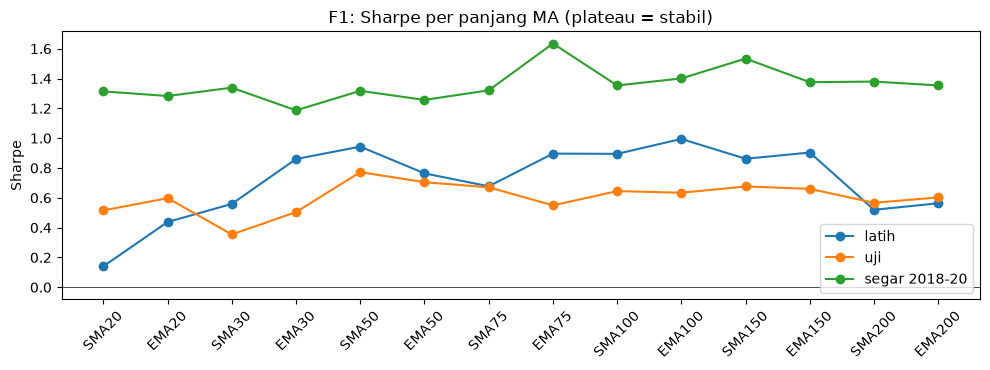

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.8))
for tag in ("latih", "uji", "segar 2018-20"):
    s = plateau[f"{tag} Sharpe"]
    ax.plot(range(len(s)), s.values, marker="o", label=tag)
ax.set_xticks(range(len(plateau))); ax.set_xticklabels(plateau.index, rotation=45)
ax.axhline(0, color="black", lw=0.5); ax.set_ylabel("Sharpe"); ax.set_title("F1: Sharpe per panjang MA (plateau = stabil)")
ax.legend(); plt.tight_layout(); plt.show()

## 8. Bootstrap Sharpe periode uji (stationary block, 2.000×)

In [9]:
def block_bootstrap_sharpe(r, n=2000, mean_block=20, seed=1):
    r = np.asarray(r); T = len(r); rng = np.random.default_rng(seed); out = np.empty(n)
    for k in range(n):
        idx, i = [], rng.integers(T)
        while len(idx) < T:
            idx.append(i)
            i = rng.integers(T) if rng.random() < 1 / mean_block else (i + 1) % T
        out[k] = daily_sharpe(r[idx]) * np.sqrt(365)
    return out

rows = []
for name, eq in {**cands, "Buy & hold BTC": run(P, hold, *TEST)[1]}.items():
    bs = block_bootstrap_sharpe(eq.pct_change().dropna())
    rows.append(dict(strategi=name, sharpe_p5=np.percentile(bs, 5), sharpe_median=np.median(bs),
                     sharpe_p95=np.percentile(bs, 95), p_sharpe_lt_0=(bs < 0).mean(),
                     p_sharpe_lt_btc=(bs < btc_test["sharpe"]).mean()))
pretty(pd.DataFrame(rows).set_index("strategi"), pct=["p_sharpe_lt_0", "p_sharpe_lt_btc"], dec=["sharpe_p5", "sharpe_median", "sharpe_p95"])

,sharpe_p5,sharpe_median,sharpe_p95,p_sharpe_lt_0,p_sharpe_lt_btc
strategi,,,,,
F2 Konservatif 07 (40 coin),-0.81,0.43,1.53,+27.0%,+52.7%
F1 tren BTC SMA50,-0.38,0.76,1.80,+14.2%,+34.1%
Buy & hold BTC,-0.62,0.45,1.52,+23.4%,+51.0%


## Kesimpulan

### A. Rotasi momentum (F2, strategi notebook 07) → ❌ **DITOLAK**
| Uji | Hasil 40 coin | (dulu, 10 coin / notebook 08) |
|---|---|---|
| PBO | **61%** — lebih buruk dari memilih acak | 37% |
| Deflated Sharpe (536 percobaan) | **15%** | 82% |
| Walk-forward 2022–2026 | **+12.8%**, DD −68% (BTC +22.8%) | +693% |
| Ranking momentum vs coin acak | **p = 43%** (R=7), 50% (R=3) — tidak lebih baik dari acak | p = 3.5% |
| Peluang Sharpe < BTC (bootstrap) | 53% | 12% |

Semua keunggulan rotasi momentum di notebook 07/08 ternyata **artefak universe 10 coin**
(coin yang dipilih karena sudah sukses). Di universe yang lebih jujur, memilih coin "terkuat"
tidak lebih baik dari memilih coin secara acak.

### B. Filter tren BTC (F1) → ⚠️ **satu-satunya edge yang konsisten, tapi sederhana & moderat**
- **Konsisten di 3 periode independen**, termasuk **data segar 2018–2020 yang belum pernah dipakai**:
  semua 14 varian MA mengalahkan buy & hold BTC dari sisi Sharpe (1.19–1.63 vs 0.85) dan drawdown
  (−33% s/d −53% vs −72%). Di periode uji, drawdown semua varian lebih kecil dari BTC (−26% s/d −41% vs −53%).
- **Timing MA50 mengalahkan timing acak** dengan exposure sama di periode penuh 2021–2026 (**p = 2.8%**);
  di periode uji saja belum signifikan (p = 14.8%, sampel pendek).
- **Panjang MA tidak penting** (PBO 72% = memilih MA "terbaik" hanya kebetulan; semua varian mirip).
  Jadi tidak perlu dioptimasi — pakai nilai standar.
- **Kelemahan**: tanpa pengaturan ukuran posisi, 2022 tetap berat (walk-forward −50%, BTC −65%);
  Deflated Sharpe 29% — manfaat utamanya **menekan risiko**, bukan melipatgandakan return.

### C. Kesimpulan besar dari seluruh riset (notebook 06 → 11)
1. **Memilih coin** (V5 ML maupun momentum) **tidak punya keunggulan yang terbukti.**
2. **Mengatur kapan berada di pasar** (filter tren BTC) adalah satu-satunya hal yang konsisten membantu —
   terutama untuk **proteksi modal**, sesuai tujuan utama spesifikasi sistem.
3. Sudah **±536 konfigurasi** dicoba. Makin banyak dicari, makin besar peluang menemukan pola palsu.
   **Pencarian parameter sebaiknya dihentikan.**

### Rekomendasi
1. Bangun sistem di atas **aturan sederhana yang ditetapkan sekarang (tidak dioptimasi lagi)**:
   *risk-on* saat close BTC > SMA50 (atau nilai tengah plateau, mis. SMA100), *risk-off* (cash) saat di bawah.
2. Saat risk-on, pegang **BTC** (atau BTC/ETH) — tidak ada bukti coin lain lebih baik.
3. Proteksi modal: ukuran posisi berbasis volatilitas + circuit breaker (sudah terbukti mengurangi
   drawdown di notebook 07/08) — **satu** uji konfirmasi di data segar 2018–2020, lalu berhenti.
4. **Paper trading ke depan** adalah satu-satunya uji yang tidak bisa di-overfit — jalankan minimal 3 bulan.